In [1]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("✅ GPU is available:", gpus)
else:
    print("❌ GPU not found. Check your CUDA/cuDNN installation.")
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import os
import numpy as np
from PIL import Image

from tensorflow.keras import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Lambda
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Input, Concatenate, UpSampling2D

2025-05-02 17:47:42.323092: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746208062.619291      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746208062.697994      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


✅ GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import os
xml_dir = '/kaggle/input/dataset/data_set/Marmot_data'
bmp_dir = '/kaggle/input/dataset/data_set/Marmot_data'

xml_files = [f for f in os.listdir(xml_dir) if f.endswith('.xml')]
valid_xml_files = [f for f in xml_files if os.path.exists(os.path.join(bmp_dir, f.replace('.xml', '.bmp')))]

# Now create dataset from valid XML files only
list_ds = tf.data.Dataset.from_tensor_slices([os.path.join(xml_dir, f) for f in valid_xml_files])


I0000 00:00:1746208076.598500      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [3]:
img_height, img_width = 256, 256

def normalize(input_image):
  input_image = tf.cast(input_image, tf.float32) / 255.0
  return input_image


def decode_img(img):
  # convert the compressed string to a 3D uint8 tensor
  img = tf.image.decode_bmp(img, channels=3)
  # resize the image to the desired size
  return tf.image.resize(img, [img_height, img_width])

def decode_mask_img(img):
  # convert the compressed string to a 2D uint8 tensor
  img = tf.image.decode_jpeg(img, channels=1)
  # resize the image to the desired size
  return tf.image.resize(img, [img_height, img_width])


def process_path(file_path):
  file_path = tf.strings.regex_replace(file_path, '.xml', '.bmp')

  mask_file_path = tf.strings.regex_replace(file_path, '.bmp', '.jpeg')

  table_mask_file_path = tf.strings.regex_replace(mask_file_path, 'Marmot_data', 'table_mask')
  column_mask_file_path = tf.strings.regex_replace(mask_file_path, 'Marmot_data', 'column_mask')

  img = normalize(decode_img(tf.io.read_file(file_path)))
  table_mask = normalize(decode_mask_img(tf.io.read_file(table_mask_file_path)))
  column_mask = normalize(decode_mask_img(tf.io.read_file(column_mask_file_path)))

  return img, {"table_output" : table_mask, "column_output" : column_mask }

In [4]:
# dataset = list_ds.map(process_path)

DATASET_SIZE = len(list(list_ds))
train_size = int(0.9 * DATASET_SIZE)
test_size = int(0.1 * DATASET_SIZE)

train = list_ds.take(train_size)
test = list_ds.skip(train_size)

TRAIN_LENGTH = len(list(train))
BATCH_SIZE = 2
BUFFER_SIZE = 1000
STEPS_PER_EPOCH = TRAIN_LENGTH // BATCH_SIZE

train = train.shuffle(BUFFER_SIZE)

train = train.map(process_path,
                      num_parallel_calls=tf.data.experimental.AUTOTUNE)

test = test.map(process_path)

train_dataset = train.batch(BATCH_SIZE).repeat().prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
test_dataset = test.batch(BATCH_SIZE)

In [5]:
def display(display_list):
  plt.figure(figsize=(15, 15))

  title = ['Input Image', 'Table Mask', 'Column Mask']

  for i in range(len(display_list)):
    plt.subplot(1, len(display_list), i+1)
    plt.title(title[i])
    plt.imshow(tf.keras.preprocessing.image.array_to_img(display_list[i]))
    plt.axis('off')
  plt.show()

(256, 256, 3)


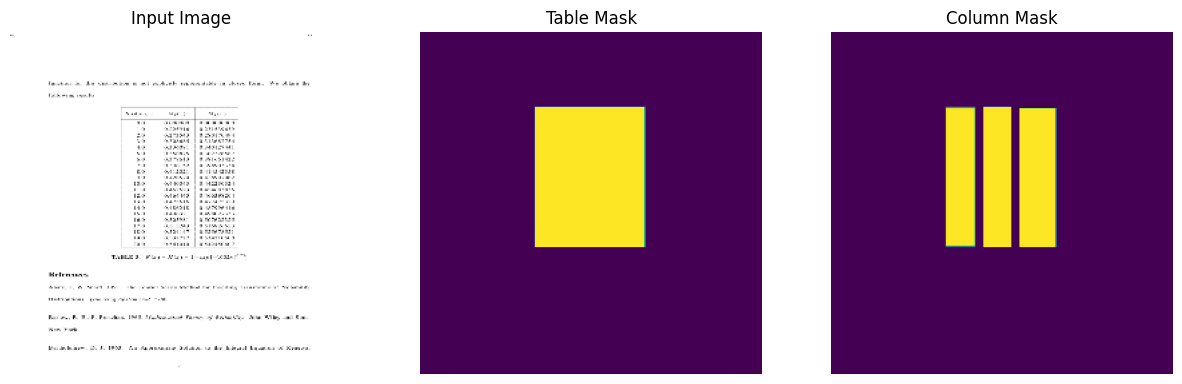

(256, 256, 3)


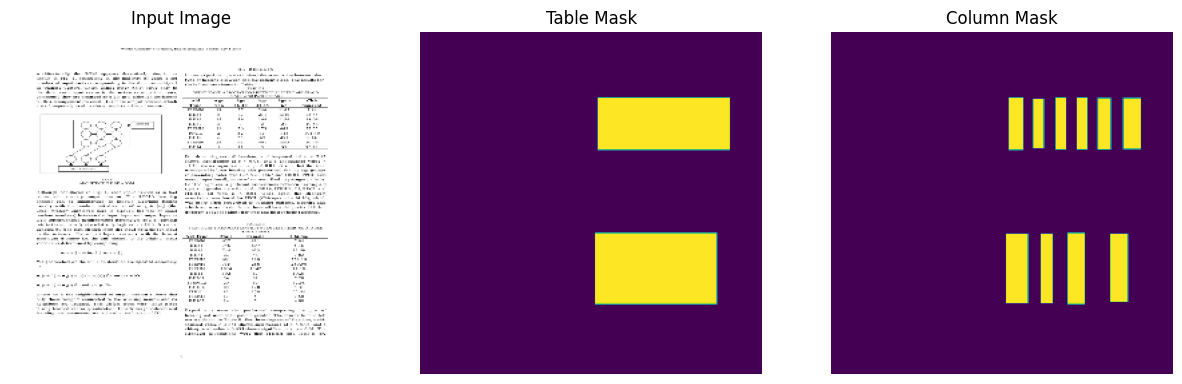

In [6]:
for image, mask  in train.take(2):
  print(image.shape)
  # print(mask.shape)
  display([image, mask['table_output'], mask['column_output']])

In [7]:
class TableNet:
  @staticmethod
  def build_table_decoder(inputs, pool3, pool4):
    x = Conv2D(512, (1, 1), activation = 'relu', name='conv7_table')(inputs)
    x = UpSampling2D(size=(2, 2))(x)

    concatenated = Concatenate()([x, pool4])

    # concatenated = concatenate([x, pool4])

    x = UpSampling2D(size=(2,2))(concatenated)
    
    concatenated = Concatenate()([x, pool3])

    x = UpSampling2D(size=(2,2))(concatenated)
    x = UpSampling2D(size=(2,2))(x)

    last = tf.keras.layers.Conv2DTranspose(
      3, 3, strides=2,
      padding='same', name='table_output') 
    
    x = last(x)

    return x

  @staticmethod
  def build_column_decoder(inputs, pool3, pool4):
    
    x = Conv2D(512, (1, 1), activation = 'relu', name='block7_conv1_column')(inputs)
    x = Dropout(0.8, name='block7_dropout_column')(x)

    x = Conv2D(512, (1, 1), activation = 'relu', name='block8_conv1_column')(x)
    x = UpSampling2D(size=(2, 2))(x)

    concatenated = Concatenate()([x, pool4])

    # concatenated = concatenate([x, pool4])

    x = UpSampling2D(size=(2,2))(concatenated)
    
    concatenated = Concatenate()([x, pool3])

    x = UpSampling2D(size=(2,2))(concatenated)
    x = UpSampling2D(size=(2,2))(x)

    last = tf.keras.layers.Conv2DTranspose(
      3, 3, strides=2,
      padding='same', name='column_output') 
    
    x = last(x)

    return x  

  @staticmethod
  def vgg_base(inputs):
    weights_path = '/kaggle/input/vgg19-weights/vgg19_weights_tf_dim_ordering_tf_kernels_notop.h5'
    base_model = tf.keras.applications.vgg19.VGG19(
    input_shape=[256, 256, 3],
    include_top=False,
    weights=weights_path)  # load local weights
    
    layer_names = ['block3_pool', 'block4_pool', 'block5_pool']
    layers = [base_model.get_layer(name).output for name in layer_names]

    pool_layers_model = Model(inputs=base_model.input, outputs=layers, name='VGG-19')
    pool_layers_model.trainable = False

    return pool_layers_model(inputs)
  
  @staticmethod
  def build():
    inputShape = (256, 256, 3)

    inputs = Input(shape=inputShape, name='input')

    pool_layers = TableNet.vgg_base(inputs)

    x = Conv2D(512, (1, 1), activation = 'relu', name='block6_conv1')(pool_layers[2])
    x = Dropout(0.8, name='block6_dropout1')(x)
    x = Conv2D(512, (1, 1), activation = 'relu', name='block6_conv2')(x)
    x = Dropout(0.8, name = 'block6_dropout2')(x)
    
    table_mask = TableNet.build_table_decoder(x, pool_layers[0], pool_layers[1])
    column_mask = TableNet.build_column_decoder(x, pool_layers[0], pool_layers[1])

    model = Model(			
              inputs=inputs,
			        outputs=[table_mask, column_mask],
			        name="tablenet")
    
    return model

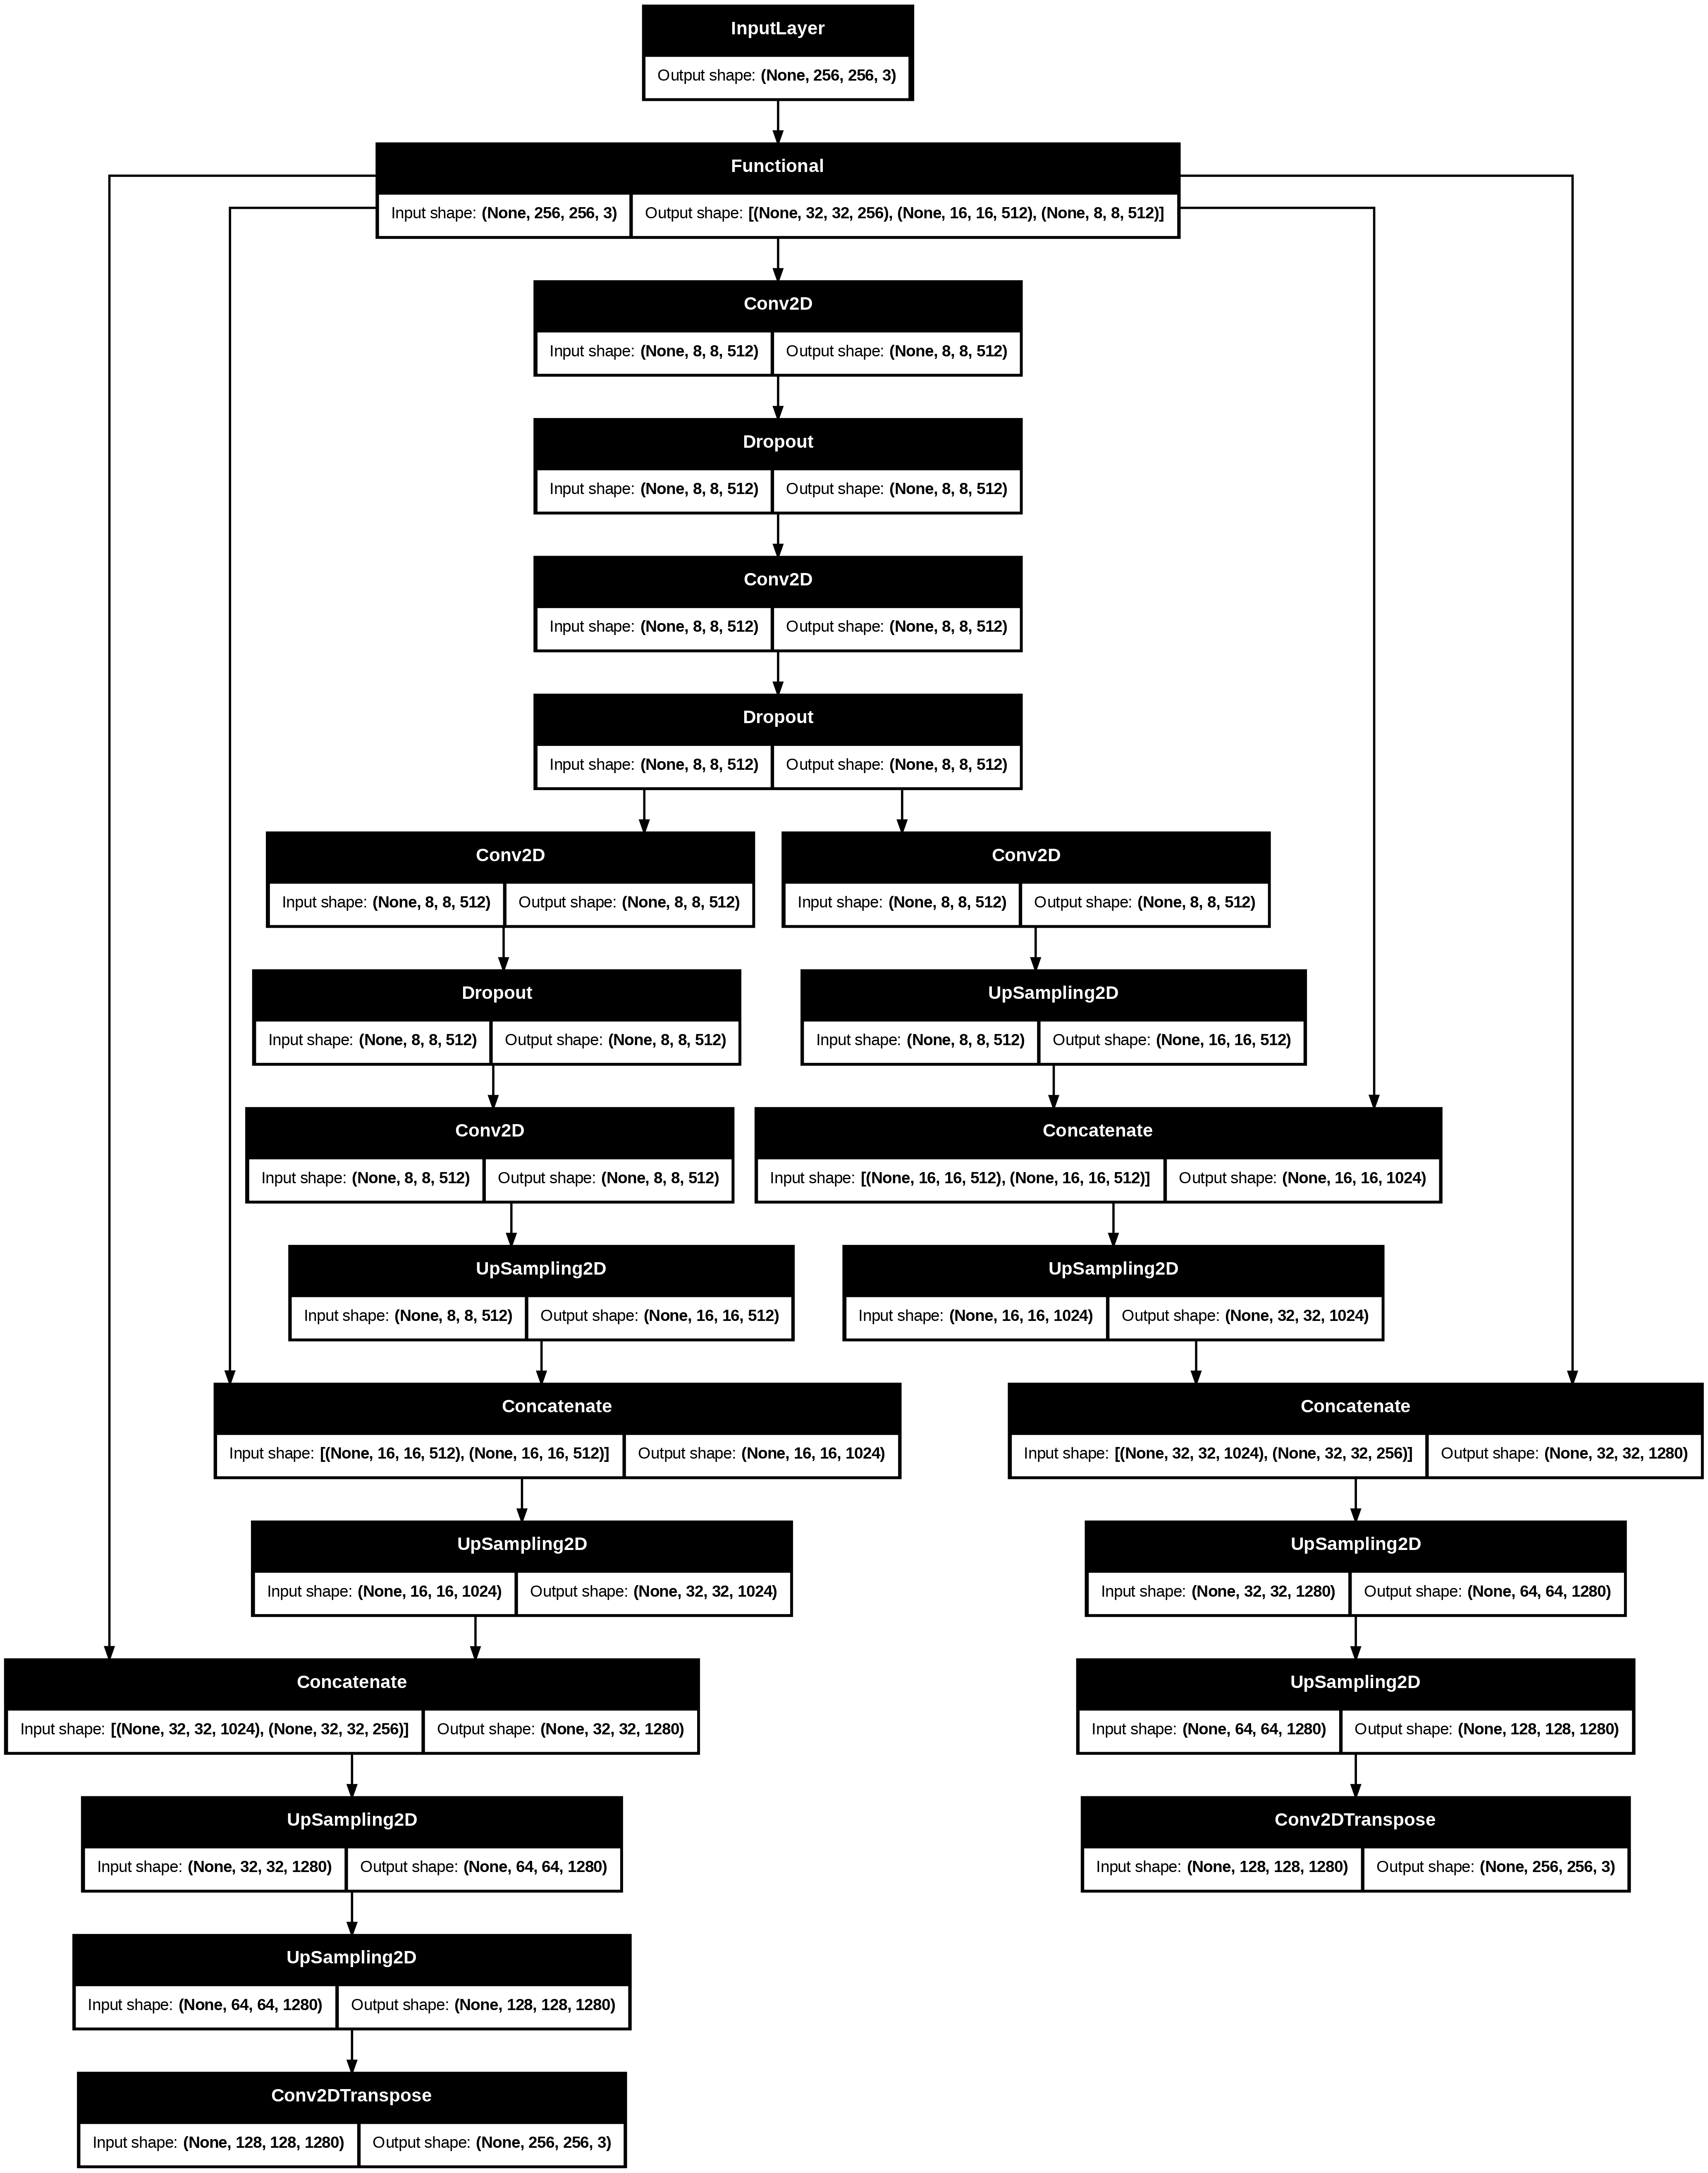

In [8]:
model = TableNet.build()
tf.keras.utils.plot_model(model, show_shapes=True)

In [9]:
losses = {
	"table_output": tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
	"column_output": tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
}

lossWeights = {"table_output": 1.0, "column_output": 1.0}

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001, epsilon=1e-08),
    loss={
        "table_output": tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        "column_output": tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    },
    metrics={
        "table_output": "accuracy",
        "column_output": "accuracy",
    },
    loss_weights={
        "table_output": 1.0,
        "column_output": 1.0,
    }
)
# model.compile(optimizer='adam',
#               loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
#               metrics=['accuracy'])

In [10]:
def create_mask(pred_mask1, pred_mask2):
  pred_mask1 = tf.argmax(pred_mask1, axis=-1)
  pred_mask1 = pred_mask1[..., tf.newaxis]


  pred_mask2 = tf.argmax(pred_mask2, axis=-1)
  pred_mask2 = pred_mask2[..., tf.newaxis]
  return pred_mask1[0], pred_mask2[0]


In [11]:
for image, mask in train_dataset.take(1):
  sample_image, sample_mask1, sample_mask2 = image, mask['table_output'], mask['column_output']

def show_predictions(dataset=None, num=1):
  if dataset:
    for image, (mask1, mask2) in dataset.take(num):
      pred_mask1, pred_mask2 = model.predict(image, verbose=1)
      table_mask, column_mask = create_mask(pred_mask1, pred_mask2)
      
      display([image[0], table_mask, column_mask])
  else:
    pred_mask1, pred_mask2 = model.predict(sample_image, verbose=1)
    table_mask, column_mask = create_mask(pred_mask1, pred_mask2)

    display([sample_image[0], table_mask, column_mask])

I0000 00:00:1746208083.329320      90 service.cc:148] XLA service 0x7e1dc400eaf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746208083.330238      90 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1746208083.563868      90 cuda_dnn.cc:529] Loaded cuDNN version 90300


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


I0000 00:00:1746208086.119599      90 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


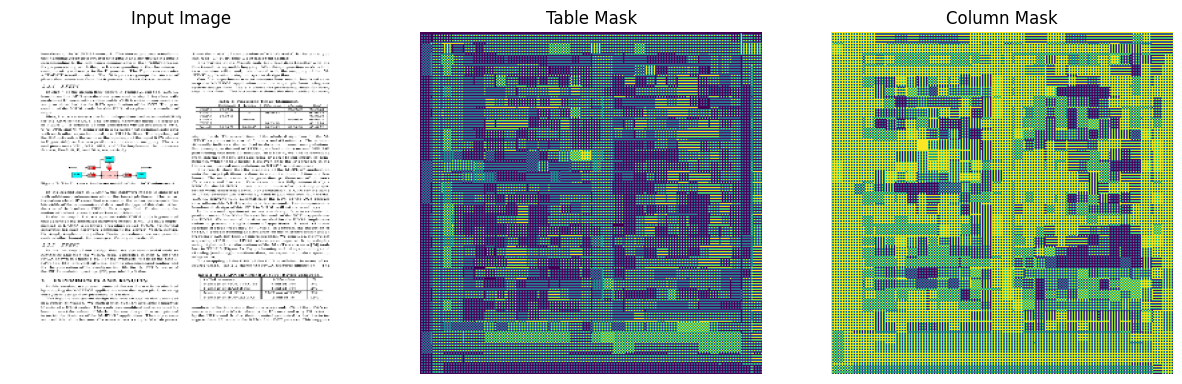

In [12]:
show_predictions()

In [13]:
from IPython.display import clear_output

class DisplayCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs=None):
    clear_output(wait=True)
    show_predictions()
    print ('\nSample Prediction after epoch {}\n'.format(epoch+1))

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
        filepath="mymodel_{epoch}.keras",
        save_best_only=True,
        monitor="val_loss",
        verbose=1,
    )

early_stoping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        verbose=1,
    )



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


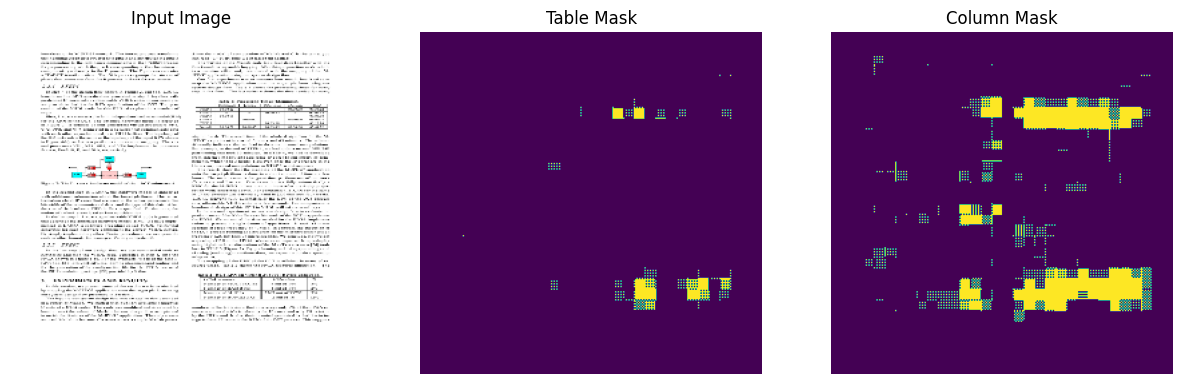


Sample Prediction after epoch 50


Epoch 50: val_loss did not improve from 0.31349
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - column_output_accuracy: 0.9072 - column_output_loss: 0.1391 - loss: 0.2880 - table_output_accuracy: 0.9051 - table_output_loss: 0.1490 - val_column_output_accuracy: 0.8692 - val_column_output_loss: 0.1874 - val_loss: 0.3503 - val_table_output_accuracy: 0.8995 - val_table_output_loss: 0.1629


In [14]:
EPOCHS = 50
VAL_SUBSPLITS = 5
VALIDATION_STEPS = test_size//BATCH_SIZE//VAL_SUBSPLITS


model_history = model.fit(train_dataset, epochs=EPOCHS,
                          steps_per_epoch=STEPS_PER_EPOCH,
                          validation_steps=VALIDATION_STEPS,
                          validation_data=test_dataset,
                          callbacks=[DisplayCallback(), model_checkpoint])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


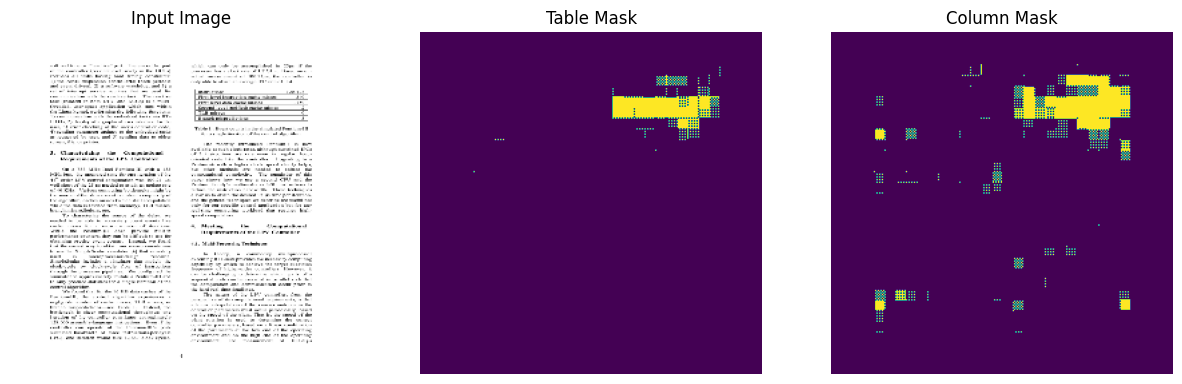

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


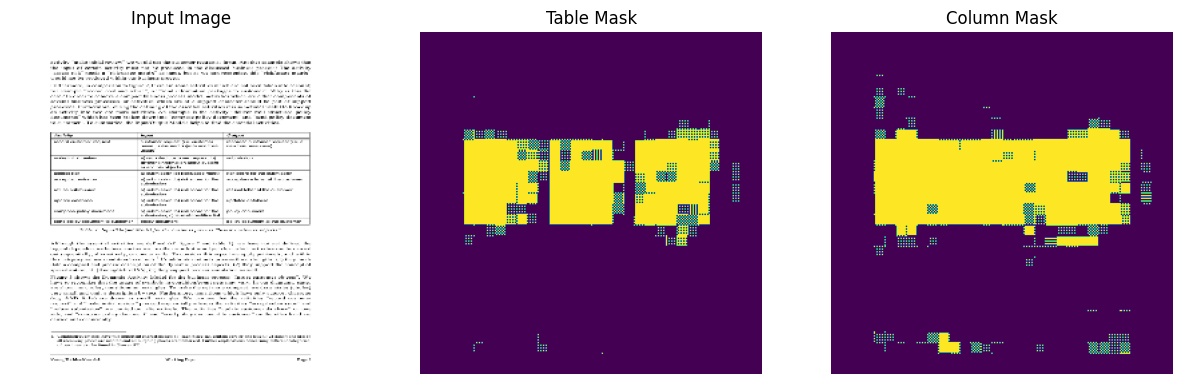

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


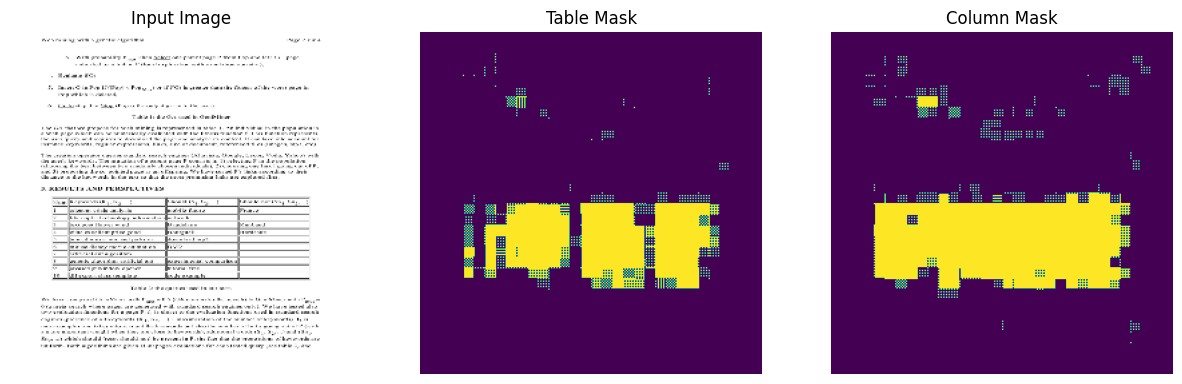

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


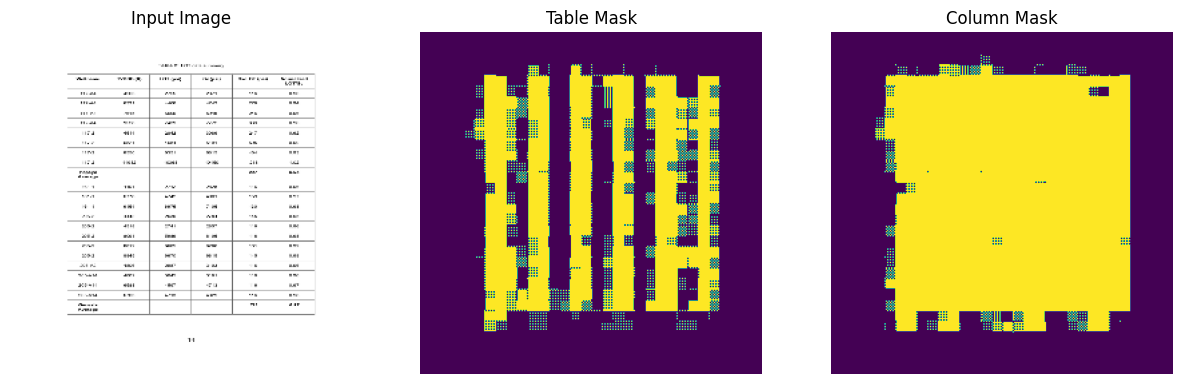

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


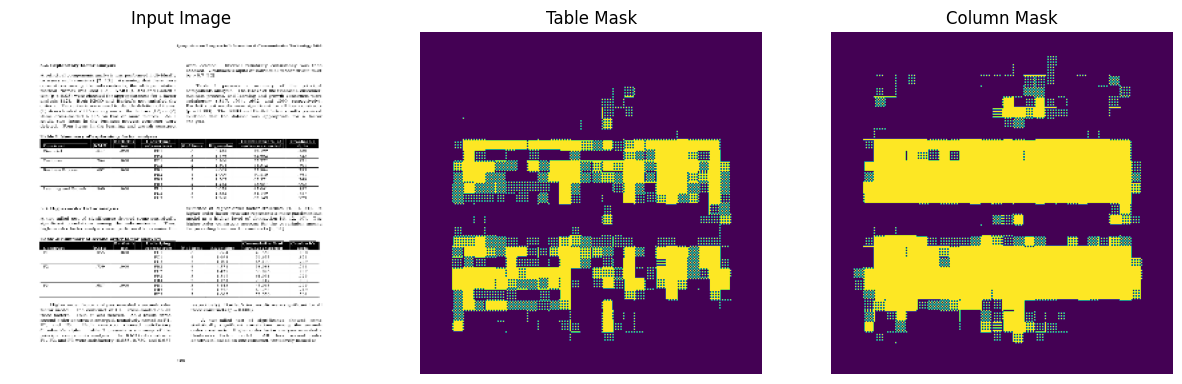

In [15]:
show_predictions(train_dataset, 5)

In [16]:
model.save('model_66.keras')

In [17]:
from tensorflow.keras.models import load_model

model = load_model('model_66.keras')

In [18]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_model(dataset, model):
    y_true_table = []
    y_pred_table = []
    y_true_column = []
    y_pred_column = []

    for image_batch, mask_dict in dataset:
        # Get true masks and convert to numpy arrays
        true_table_mask = mask_dict['table_output'].numpy()
        true_column_mask = mask_dict['column_output'].numpy()
        
        # Predict using model
        pred_table_mask, pred_column_mask = model.predict(image_batch)
        
        # Reshape all masks to be 2D (height x width)
        true_table_mask = true_table_mask.reshape(-1)
        true_column_mask = true_column_mask.reshape(-1)
        pred_table_mask = pred_table_mask.reshape(-1, pred_table_mask.shape[-1])
        pred_column_mask = pred_column_mask.reshape(-1, pred_column_mask.shape[-1])
        
        # Convert predictions to class labels (0 or 1)
        pred_table_mask = np.argmax(pred_table_mask, axis=-1)
        pred_column_mask = np.argmax(pred_column_mask, axis=-1)
        
        # Threshold true masks in case they're float (0-1)
        true_table_mask = (true_table_mask > 0.5).astype(np.uint8)
        true_column_mask = (true_column_mask > 0.5).astype(np.uint8)
        
        y_true_table.extend(true_table_mask)
        y_pred_table.extend(pred_table_mask)
        y_true_column.extend(true_column_mask)
        y_pred_column.extend(pred_column_mask)

    # Calculate metrics
    table_recall = recall_score(y_true_table, y_pred_table)
    table_precision = precision_score(y_true_table, y_pred_table)
    table_f1 = f1_score(y_true_table, y_pred_table)
    
    column_recall = recall_score(y_true_column, y_pred_column)
    column_precision = precision_score(y_true_column, y_pred_column)
    column_f1 = f1_score(y_true_column, y_pred_column)

    # Print results in table format
    print("Model Evaluation Results")
    print("-------------------------------------------------")
    print("{:<40} {:<10} {:<10} {:<10}".format('Model', 'Recall', 'Precision', 'F1-Score'))
    print("-------------------------------------------------")
    print("{:<40} {:<10.4f} {:<10.4f} {:<10.4f}".format(
        'Table Detection', 
        table_recall, 
        table_precision, 
        table_f1))
    print("{:<40} {:<10.4f} {:<10.4f} {:<10.4f}".format(
        'Column Detection', 
        column_recall, 
        column_precision, 
        column_f1))
    print("-------------------------------------------------")

In [19]:
evaluate_model(test_dataset, model)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Model Evaluation Results
---------------------------

In [20]:
import zipfile

model_path = "/kaggle/working/model_66.keras"
zip_path = "/kaggle/working/model_66.zip"

with zipfile.ZipFile(zip_path, 'w') as zipf:
    zipf.write(model_path, arcname="model_66.keras")

In [21]:
!copy model66.zip "H:\\University works(NSU)\\CSE 465\\project\\TableNet-master\\model"

/bin/bash: line 1: copy: command not found


In [22]:
model = load_model('model_66.keras')  # Your saved model

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


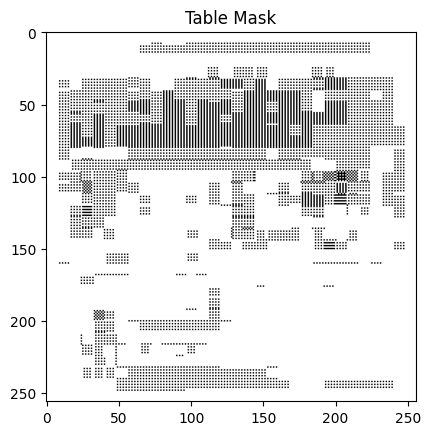

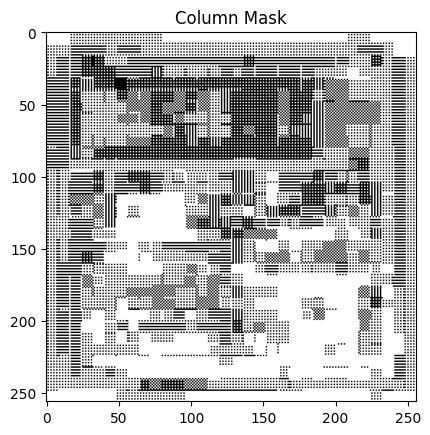

In [23]:
for image, mask in test_dataset.take(1):
    # Predict for a single image (use image[0] if batch_size > 1)
    pred_table_mask, pred_column_mask = model.predict(tf.expand_dims(image[0], axis=0))
    
    # Remove batch and channel dimensions (keep only H x W)
    table_mask = (pred_table_mask[0, ..., 0] > 0.5).astype(np.uint8)  # Shape: (256, 256)
    column_mask = (pred_column_mask[0, ..., 0] > 0.5).astype(np.uint8)
    
    # Display
    plt.imshow(table_mask, cmap='gray')
    plt.title("Table Mask")
    plt.show()
    
    plt.imshow(column_mask, cmap='gray')
    plt.title("Column Mask")
    plt.show()

In [24]:
import sys
!{sys.executable} -m pip install opencv-python

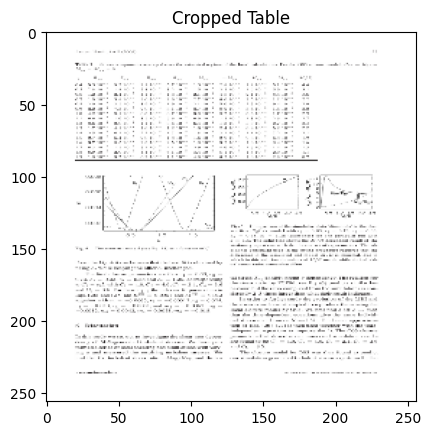

In [25]:
import cv2
import numpy as np

# Ensure table_mask is a numpy array with dtype=uint8
table_mask = table_mask.astype(np.uint8)

# Find contours
contours, _ = cv2.findContours(table_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Get the largest contour
if contours:  # Check if contours were found
    table_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(table_contour)
    
    # Crop the table region
    table_roi = image[0].numpy()[y:y+h, x:x+w]
    plt.imshow(table_roi)
    plt.title("Cropped Table")
    plt.show()
else:
    print("No contours found in the mask!")

In [26]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import pytesseract
from tensorflow.keras.models import load_model

# Optional: improve OCR by configuring pytesseract
custom_config = r'--oem 3 --psm 6'

print("Libraries loaded.")

Libraries loaded.


In [27]:
# Load the trained model
model = load_model('/kaggle/working/model_66.keras')

# Set your dataset path (e.g., test images directory if not tf.data.Dataset)
# Assuming you're using a tf.data.Dataset named test_dataset already.

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


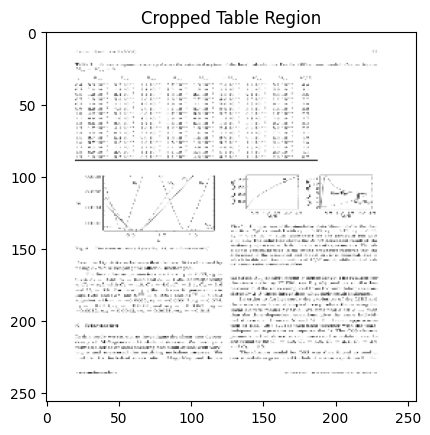

In [28]:
for image, mask in test_dataset.take(1):
    pred_table_mask, _ = model.predict(tf.expand_dims(image[0], axis=0))

    # Threshold and convert to uint8
    table_mask = (pred_table_mask[0, ..., 0] > 0.5).astype(np.uint8)

    # Find contours
    contours, _ = cv2.findContours(table_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        # Get largest table
        table_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(table_contour)

        # Crop table from original image
        image_np = (image[0].numpy() * 255).astype(np.uint8)  # convert to uint8 for cv2
        if image_np.shape[-1] == 1:  # If grayscale
            image_np = np.squeeze(image_np, axis=-1)
        cropped_table = image_np[y:y+h, x:x+w]

        plt.imshow(cropped_table, cmap='gray' if cropped_table.ndim == 2 else None)
        plt.title("Cropped Table Region")
        plt.show()
    else:
        print("No table found.")

In [29]:
# Convert to grayscale if needed
if cropped_table.ndim == 3:
    gray = cv2.cvtColor(cropped_table, cv2.COLOR_RGB2GRAY)
else:
    gray = cropped_table

# Apply OCR using pytesseract
ocr_result = pytesseract.image_to_string(gray, config=custom_config)

# Split OCR result into lines and cells
rows = [line.split() for line in ocr_result.strip().split('\n') if line.strip()]

# Save to CSV
import csv

csv_path = "/kaggle/working/extracted_table2.csv"
with open(csv_path, mode='w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    for row in rows:
        writer.writerow(row)

print("Saved extracted table to:", csv_path)

Saved extracted table to: /kaggle/working/extracted_table2.csv


Processing image 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


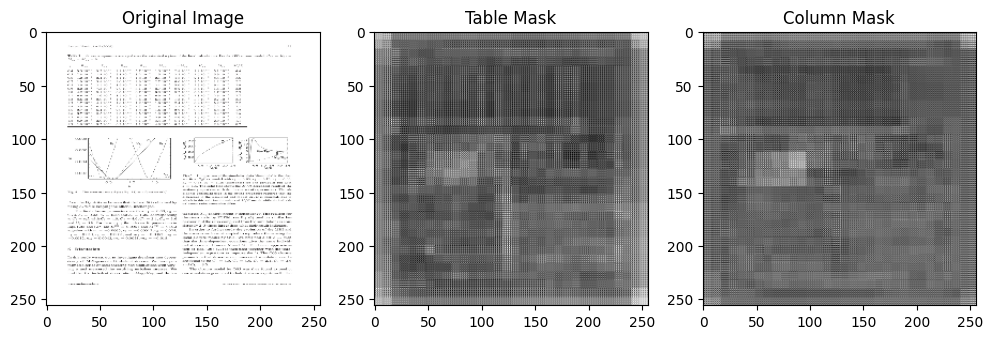

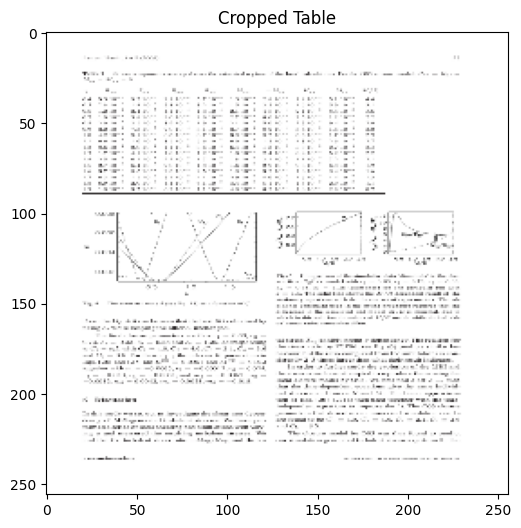

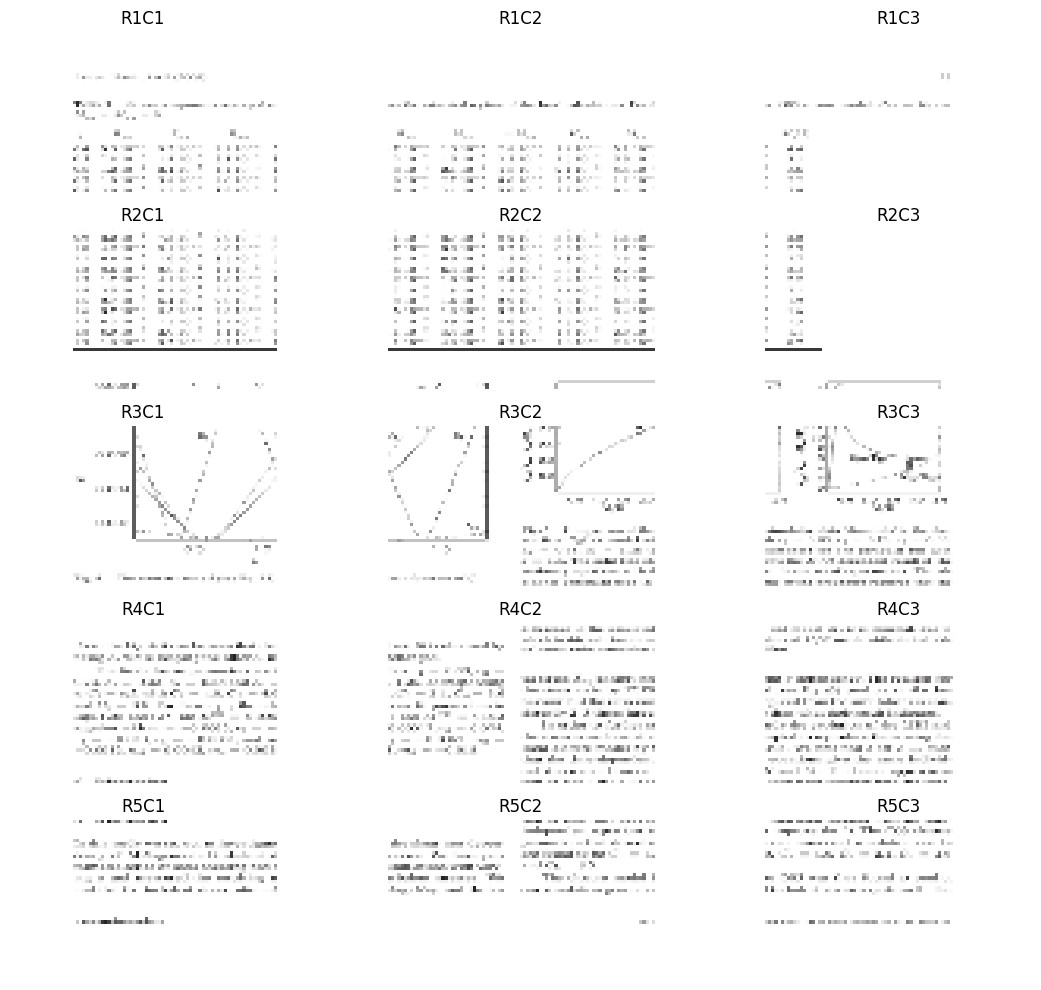

Table structure saved to extracted_tables/table_1.csv
Table structure:
      0     1     2
0  R1C1  R1C2  R1C3
1  R2C1  R2C2  R2C3
2  R3C1  R3C2  R3C3
3  R4C1  R4C2  R4C3
4  R5C1  R5C2  R5C3
Processing image 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


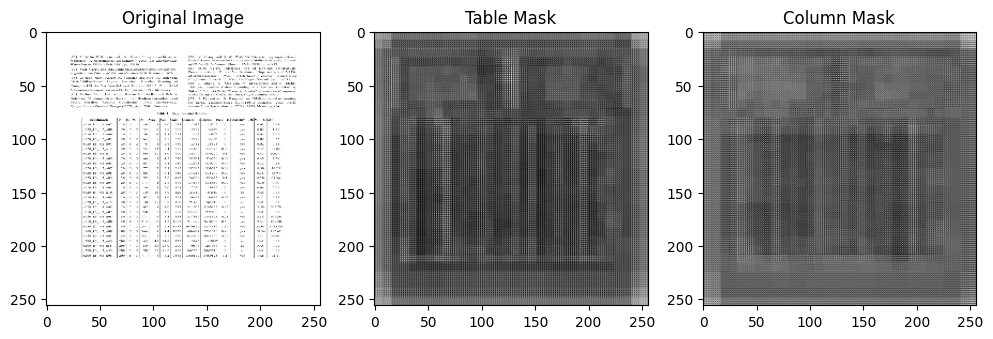

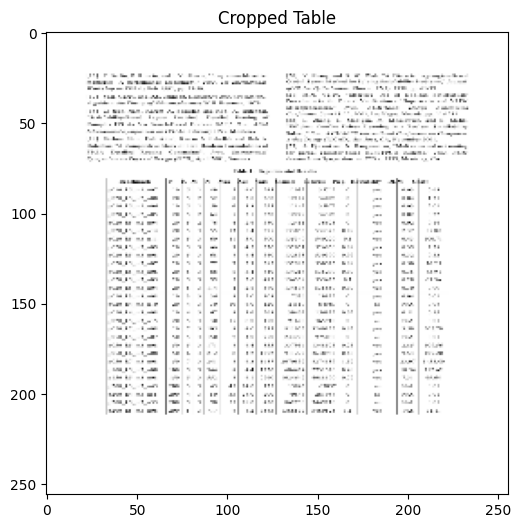

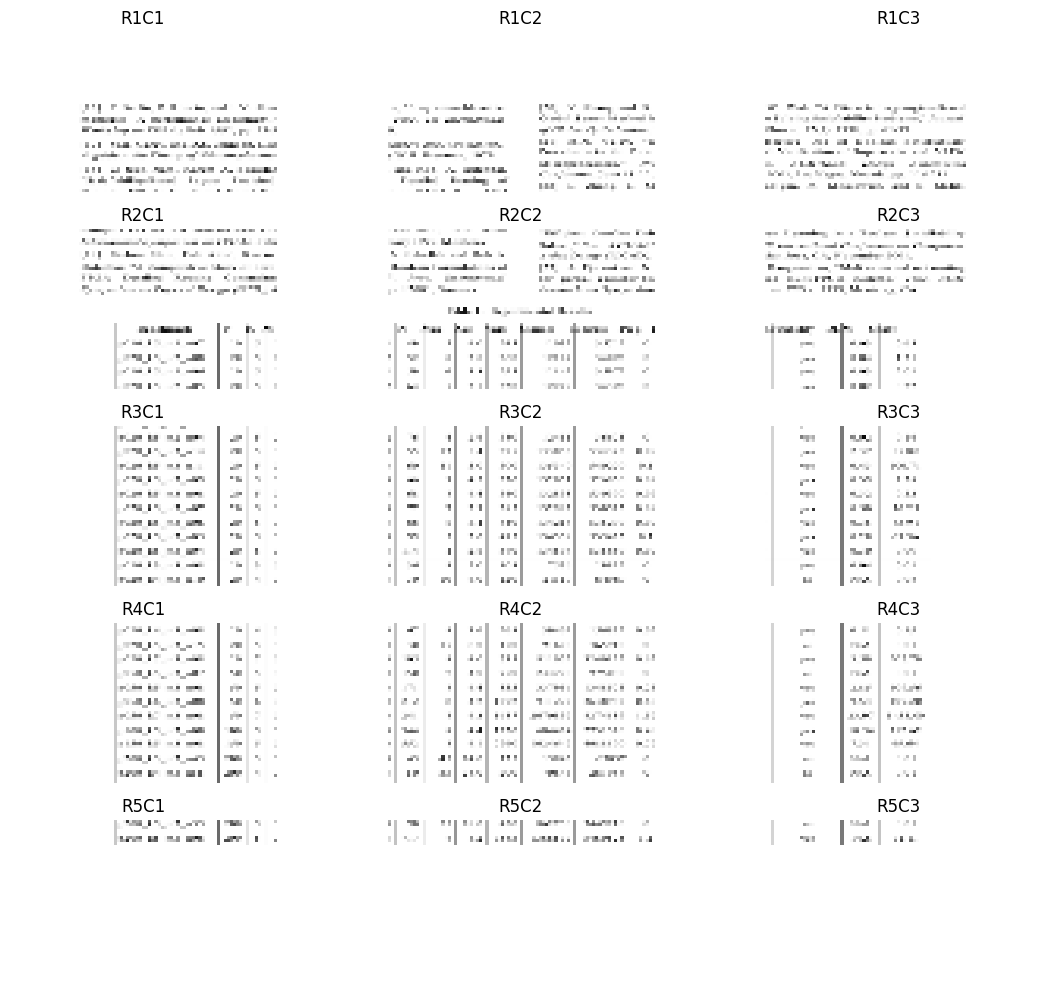

Table structure saved to extracted_tables/table_2.csv
Table structure:
      0     1     2
0  R1C1  R1C2  R1C3
1  R2C1  R2C2  R2C3
2  R3C1  R3C2  R3C3
3  R4C1  R4C2  R4C3
4  R5C1  R5C2  R5C3
Processing image 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


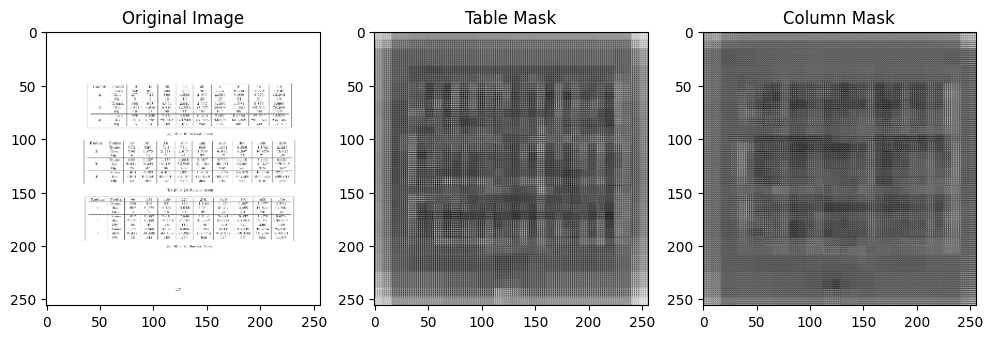

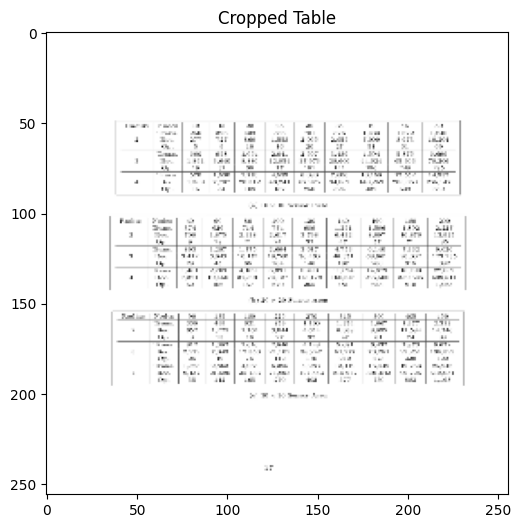

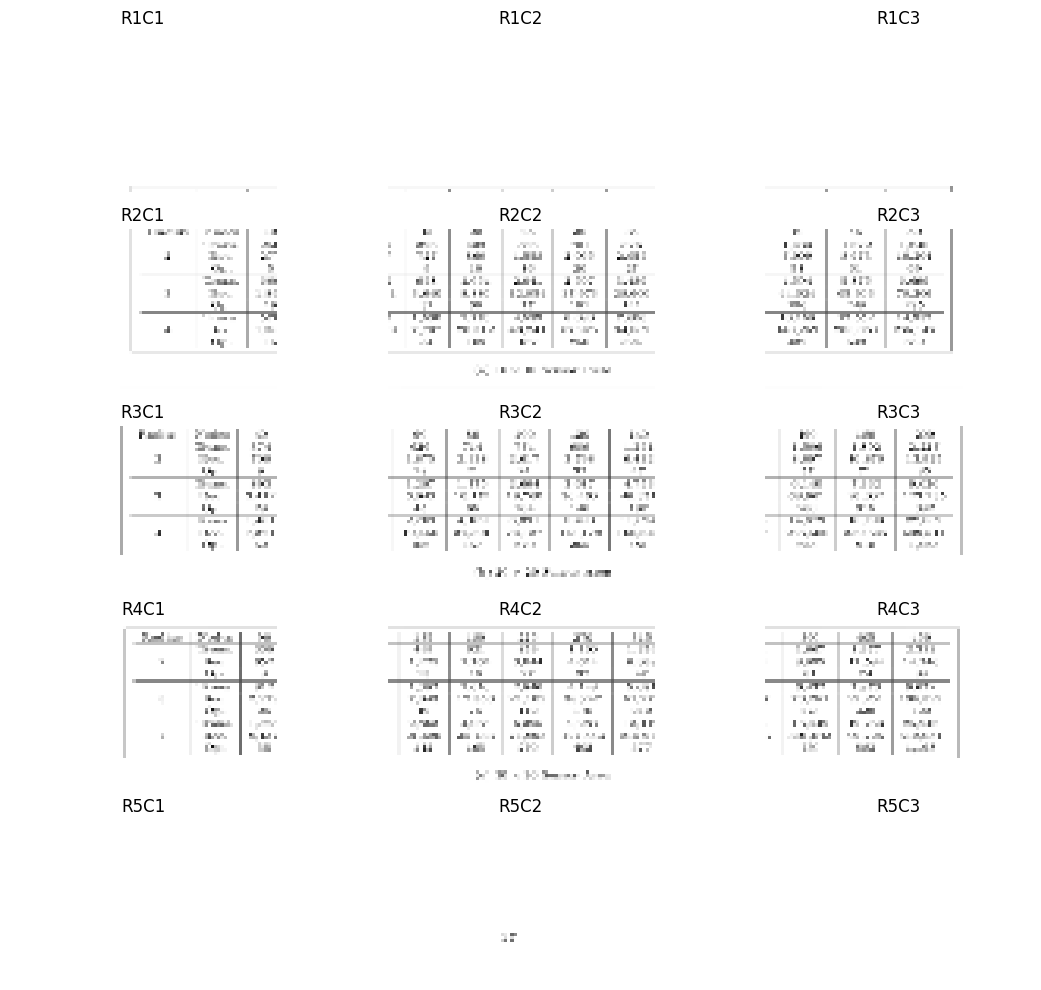

Table structure saved to extracted_tables/table_3.csv
Table structure:
      0     1     2
0  R1C1  R1C2  R1C3
1  R2C1  R2C2  R2C3
2  R3C1  R3C2  R3C3
3  R4C1  R4C2  R4C3
4  R5C1  R5C2  R5C3


In [30]:
# Cell 1: Install necessary packages
import sys
!{sys.executable} -m pip install opencv-python pandas

# Cell 2: Import libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import pandas as pd
import os
from tensorflow.keras.models import load_model

# Cell 3: Load your model
model = load_model('model_66.keras')

# Define your dataset path or create a dataset
# test_dataset = ...

# Cell 4: Simple table extraction function
def extract_table_data(image, table_mask, csv_path):
    """Extract table data from an image using table mask and save to CSV"""
    # Convert image to numpy if it's a tensor
    if isinstance(image, tf.Tensor):
        image = image.numpy()
    
    # Ensure image is uint8
    if image.dtype != np.uint8:
        image = (image * 255).astype(np.uint8)
    
    # Convert mask to binary uint8
    table_mask = (table_mask > 0.5).astype(np.uint8)
    
    # Find table contour
    contours, _ = cv2.findContours(table_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        print("No table found in image")
        return None
    
    # Get the largest contour (assumed to be the table)
    table_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(table_contour)
    
    # Crop the table region
    table_roi = image[y:y+h, x:x+w]
    
    # Display cropped table
    plt.figure(figsize=(10, 6))
    plt.imshow(table_roi)
    plt.title("Cropped Table")
    plt.show()
    
    # For a simple approach, we'll divide the table into a grid
    # You can adjust these numbers based on your table structure
    rows = 5  # Estimated number of rows
    cols = 3  # Estimated number of columns
    
    cell_height = h // rows
    cell_width = w // cols
    
    # Extract cell regions
    cells = []
    for r in range(rows):
        row_cells = []
        for c in range(cols):
            # Get cell coordinates
            cell_x = x + c * cell_width
            cell_y = y + r * cell_height
            
            # Save cell region for visualization
            cell_roi = image[cell_y:cell_y+cell_height, cell_x:cell_x+cell_width]
            row_cells.append(cell_roi)
        cells.append(row_cells)
    
    # Visualize cells
    fig, axes = plt.subplots(rows, cols, figsize=(12, 10))
    for r in range(rows):
        for c in range(cols):
            if rows > 1:
                ax = axes[r, c]
            else:
                ax = axes[c]
            ax.imshow(cells[r][c])
            ax.set_title(f"R{r+1}C{c+1}")
            ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    # For now, we'll create a placeholder CSV with cell positions
    # In a real application, you would use OCR to extract text from each cell
    data = []
    for r in range(rows):
        row_data = [f"R{r+1}C{c+1}" for c in range(cols)]
        data.append(row_data)
    
    # Save to CSV
    df = pd.DataFrame(data)
    df.to_csv(csv_path, index=False, header=False)
    print(f"Table structure saved to {csv_path}")
    
    return df

# Cell 5: Process images and extract tables
output_dir = "extracted_tables"
os.makedirs(output_dir, exist_ok=True)

# Process a few images
for idx, (image, mask) in enumerate(test_dataset.take(3)):
    print(f"Processing image {idx+1}")
    
    # Predict masks
    pred_table_mask, pred_column_mask = model.predict(tf.expand_dims(image[0], axis=0))
    
    # Get the table mask (remove batch and channel dimensions)
    table_mask = pred_table_mask[0, ..., 0]
    
    # Display masks
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(image[0])
    plt.title("Original Image")
    
    plt.subplot(1, 3, 2)
    plt.imshow(table_mask, cmap='gray')
    plt.title("Table Mask")
    
    plt.subplot(1, 3, 3)
    plt.imshow(pred_column_mask[0, ..., 0], cmap='gray')
    plt.title("Column Mask")
    plt.show()
    
    # Extract table data
    output_csv = os.path.join(output_dir, f"table_{idx+1}.csv")
    df = extract_table_data(image[0], table_mask, output_csv)
    
    # Show extracted data (placeholder format)
    if df is not None:
        print("Table structure:")
        print(df)

Processing image 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


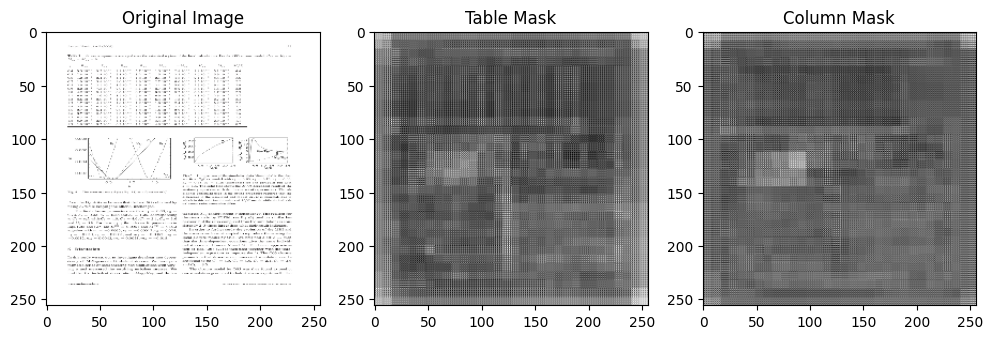

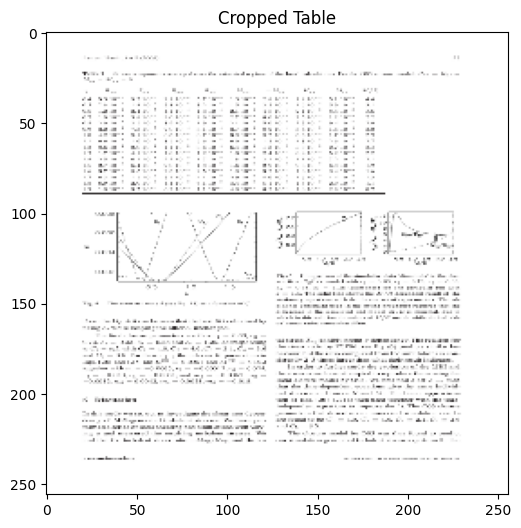

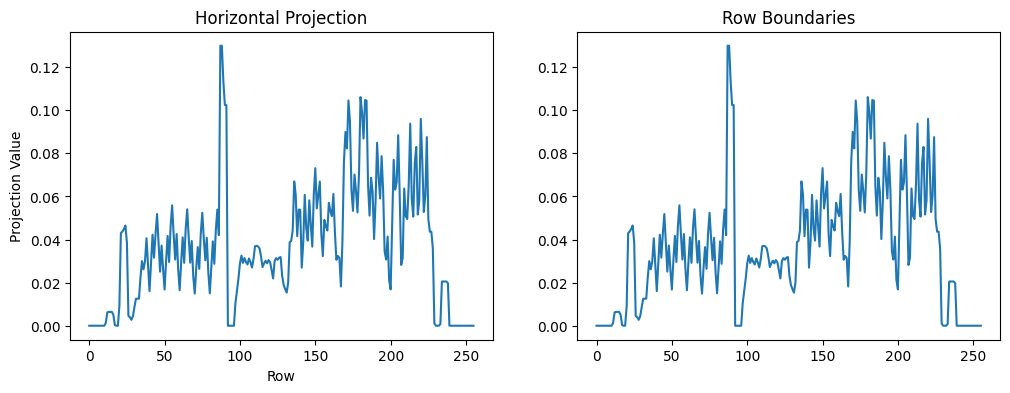

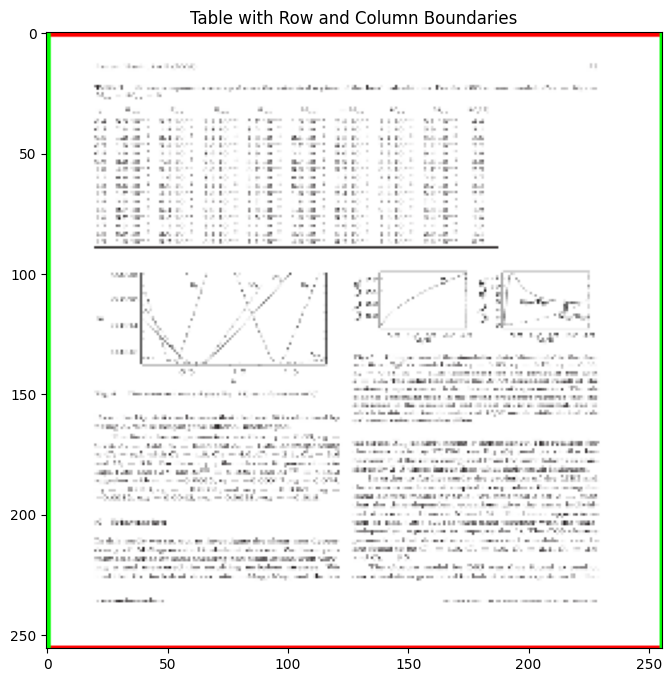

Table data saved to extracted_tables/table_1.csv
Extracted table structure:
           0
0  Text[1,1]
Processing image 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


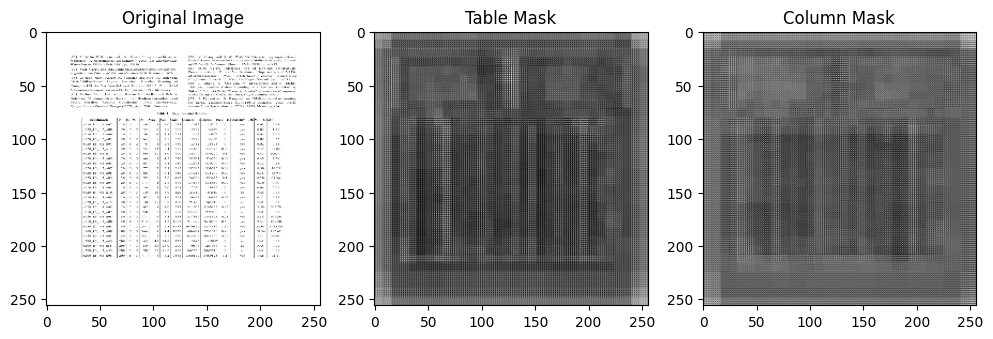

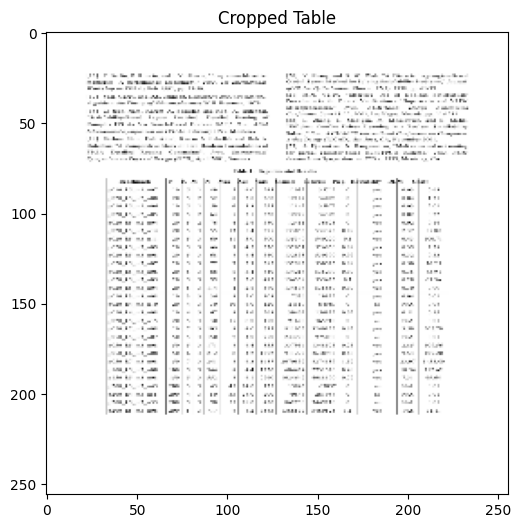

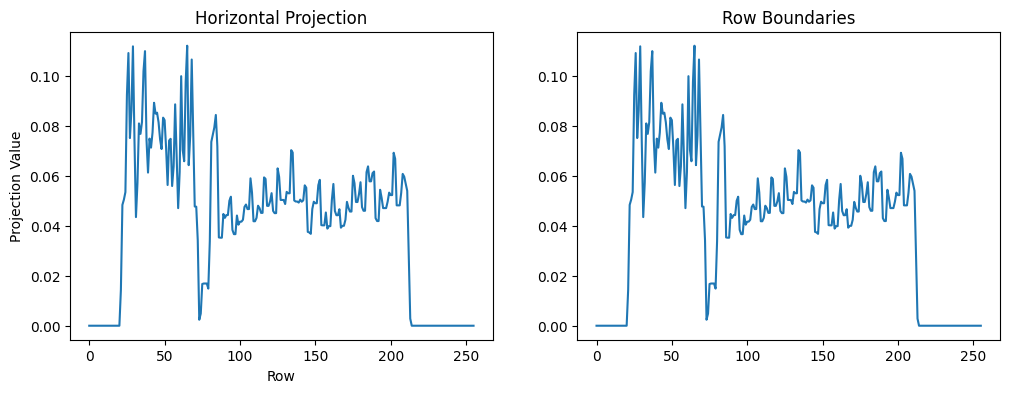

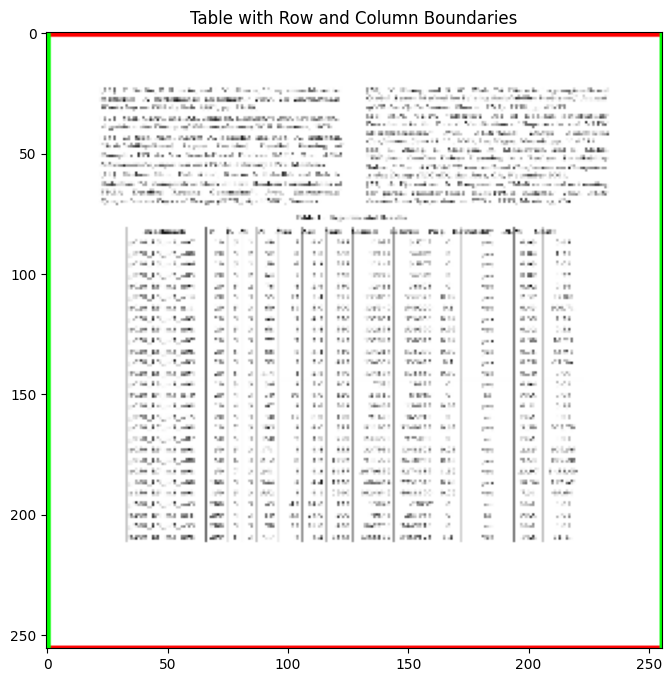

Table data saved to extracted_tables/table_2.csv
Extracted table structure:
           0
0  Text[1,1]
Processing image 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


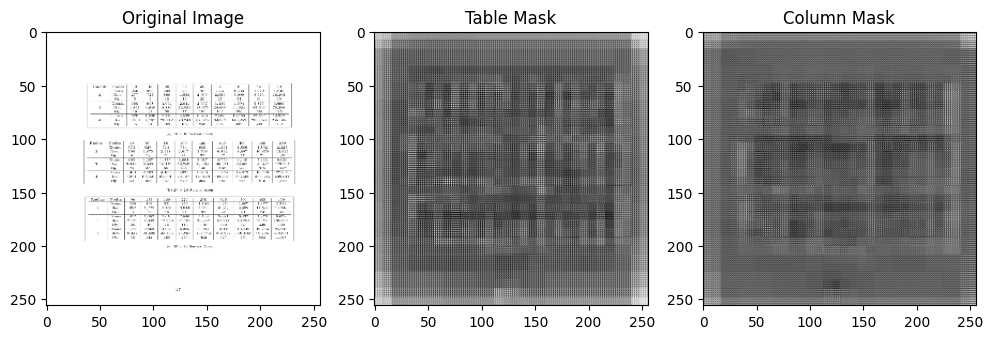

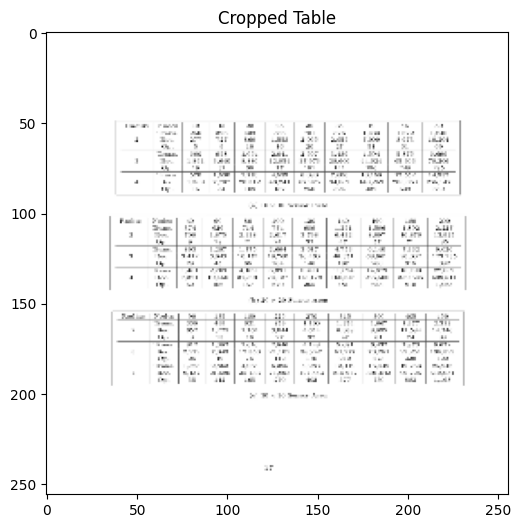

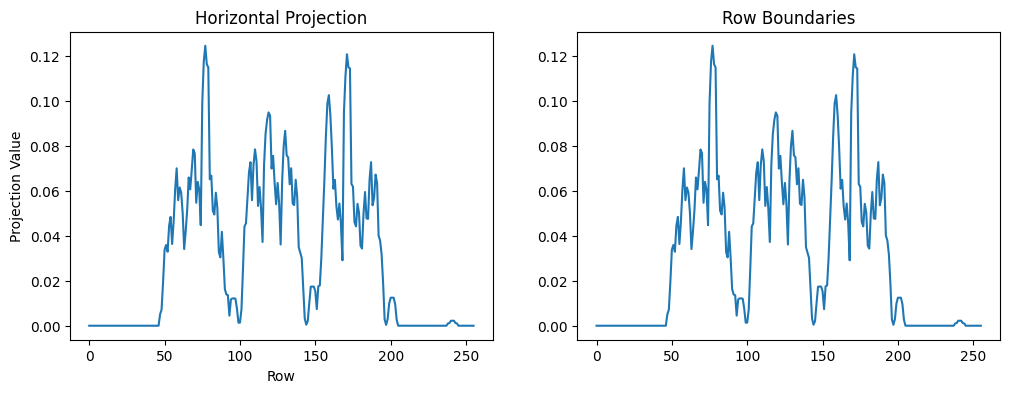

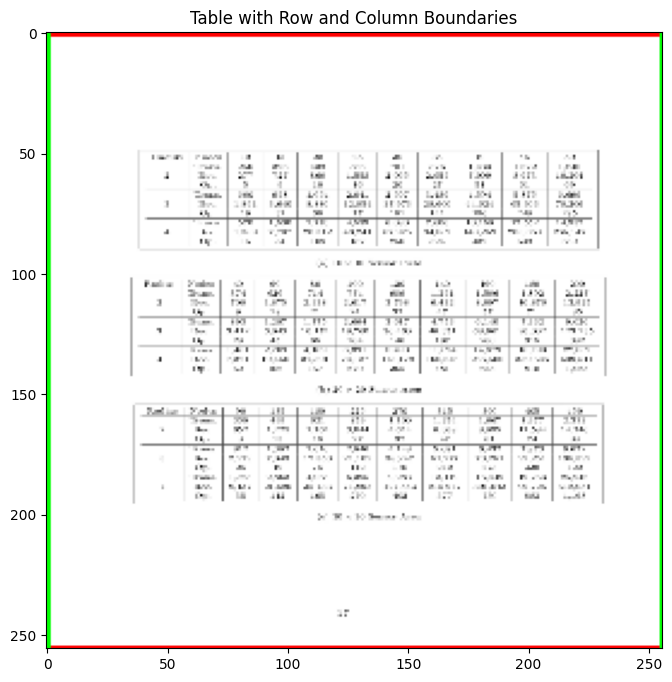

Table data saved to extracted_tables/table_3.csv
Extracted table structure:
           0
0  Text[1,1]


In [31]:
# Cell 1: Install necessary packages
import sys
!{sys.executable} -m pip install opencv-python pandas scikit-image

# Cell 2: Import libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import pandas as pd
import os
from tensorflow.keras.models import load_model
from skimage.filters import threshold_otsu
from skimage import measure

# Cell 3: Load your model
model = load_model('model_66.keras')

# Define your dataset path or create a dataset
# test_dataset = ...

# Cell 4: Enhanced table extraction function
def extract_table_data(image, table_mask, column_mask, csv_path):
    """Extract table data from an image using masks and save to CSV"""
    # Convert image to numpy if it's a tensor
    if isinstance(image, tf.Tensor):
        image = image.numpy()
    
    # Ensure image is uint8
    if image.dtype != np.uint8:
        image = (image * 255).astype(np.uint8)
    
    # Convert masks to binary uint8
    table_mask = (table_mask > 0.5).astype(np.uint8)
    column_mask = (column_mask > 0.5).astype(np.uint8)
    
    # Find table contour
    contours, _ = cv2.findContours(table_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        print("No table found in image")
        return None
    
    # Get the largest contour (assumed to be the table)
    table_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(table_contour)
    
    # Crop the table region
    table_roi = image[y:y+h, x:x+w]
    column_mask_roi = column_mask[y:y+h, x:x+w]
    
    # Display cropped table
    plt.figure(figsize=(10, 6))
    plt.imshow(table_roi)
    plt.title("Cropped Table")
    plt.show()
    
    # Step 1: Find row boundaries
    # Convert to grayscale for processing
    if len(table_roi.shape) == 3:
        gray_roi = cv2.cvtColor(table_roi, cv2.COLOR_RGB2GRAY)
    else:
        gray_roi = table_roi
    
    # Create a horizontal projection profile
    h_projection = np.sum(gray_roi, axis=1)
    
    # Normalize and invert the projection
    h_projection = h_projection / np.max(h_projection)
    h_projection = 1 - h_projection  # Invert so that lines correspond to peaks
    
    # Smooth the projection to reduce noise
    h_projection = np.convolve(h_projection, np.ones(5)/5, mode='same')
    
    # Plot the horizontal projection
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(h_projection)
    plt.title('Horizontal Projection')
    plt.xlabel('Row')
    plt.ylabel('Projection Value')
    
    # Find peaks in the projection (row boundaries)
    from scipy.signal import find_peaks
    h_peaks, _ = find_peaks(h_projection, height=0.2, distance=20)
    
    # Add start and end positions
    row_boundaries = [0] + list(h_peaks) + [h]
    
    # Plot peaks on projection
    plt.subplot(1, 2, 2)
    plt.plot(h_projection)
    plt.plot(h_peaks, h_projection[h_peaks], "x")
    plt.title('Row Boundaries')
    plt.show()
    
    # Step 2: Find column boundaries using column mask
    # Find contours in the column mask
    col_contours, _ = cv2.findContours(column_mask_roi, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Get x-coordinates of column contours
    col_x_coords = []
    if col_contours:
        for contour in col_contours:
            col_x, _, col_w, _ = cv2.boundingRect(contour)
            col_x_coords.append(col_x)
            col_x_coords.append(col_x + col_w)
    
    # Sort and remove duplicates
    col_x_coords = sorted(list(set(col_x_coords)))
    
    # If no columns detected, use simple division
    if len(col_x_coords) <= 1:
        num_cols = 3  # Estimated number of columns
        col_width = w // num_cols
        col_boundaries = [c * col_width for c in range(num_cols+1)]
    else:
        col_boundaries = [0] + col_x_coords + [w]
        # Remove duplicates and very close boundaries
        col_boundaries = sorted(list(set(col_boundaries)))
        i = 1
        while i < len(col_boundaries):
            if col_boundaries[i] - col_boundaries[i-1] < 10:  # Too close
                col_boundaries.pop(i)
            else:
                i += 1
    
    # Visualize the table with row and column lines
    table_vis = table_roi.copy()
    
    # Draw row boundaries
    for r in row_boundaries:
        cv2.line(table_vis, (0, r), (w, r), (255, 0, 0), 2)
    
    # Draw column boundaries
    for c in col_boundaries:
        cv2.line(table_vis, (c, 0), (c, h), (0, 255, 0), 2)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(table_vis)
    plt.title("Table with Row and Column Boundaries")
    plt.show()
    
    # Step 3: Extract cell content using the grid
    # We'll analyze cells for content by measuring the amount of ink/text
    cell_data = []
    
    for i in range(len(row_boundaries)-1):
        row_cells = []
        for j in range(len(col_boundaries)-1):
            # Extract cell region
            cell_y1 = row_boundaries[i]
            cell_y2 = row_boundaries[i+1]
            cell_x1 = col_boundaries[j]
            cell_x2 = col_boundaries[j+1]
            
            # Skip very small cells
            if cell_y2 - cell_y1 < 5 or cell_x2 - cell_x1 < 5:
                row_cells.append("")
                continue
                
            cell = gray_roi[cell_y1:cell_y2, cell_x1:cell_x2]
            
            # Analyze cell content (simplified approach)
            # Threshold the cell to separate text from background
            try:
                thresh = threshold_otsu(cell)
                binary_cell = cell < thresh  # True for dark pixels (text)
                
                # Count foreground pixels (text)
                text_pixel_count = np.sum(binary_cell)
                cell_area = cell.shape[0] * cell.shape[1]
                
                # If the cell has enough dark pixels, it likely contains text
                if text_pixel_count / cell_area > 0.03:  # Adjust threshold as needed
                    content = f"Text[{i+1},{j+1}]"  # Placeholder for text content
                else:
                    content = ""  # Empty cell
            except:
                content = f"Error[{i+1},{j+1}]"
                
            row_cells.append(content)
        
        cell_data.append(row_cells)
    
    # Step 4: Convert to DataFrame and save to CSV
    df = pd.DataFrame(cell_data)
    
    # Clean up the DataFrame (remove empty rows/columns)
    # Remove rows with all empty cells
    df = df.loc[~(df == "").all(axis=1)]
    # Remove columns with all empty cells
    df = df.loc[:, ~(df == "").all(axis=0)]
    
    df.to_csv(csv_path, index=False, header=False)
    print(f"Table data saved to {csv_path}")
    
    return df

# Cell 5: Process images and extract tables
output_dir = "extracted_tables"
os.makedirs(output_dir, exist_ok=True)

# Process a few images
for idx, (image, mask) in enumerate(test_dataset.take(3)):
    print(f"Processing image {idx+1}")
    
    # Predict masks
    pred_table_mask, pred_column_mask = model.predict(tf.expand_dims(image[0], axis=0))
    
    # Get the masks (remove batch and channel dimensions)
    table_mask = pred_table_mask[0, ..., 0]
    column_mask = pred_column_mask[0, ..., 0]
    
    # Display masks
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(image[0])
    plt.title("Original Image")
    
    plt.subplot(1, 3, 2)
    plt.imshow(table_mask, cmap='gray')
    plt.title("Table Mask")
    
    plt.subplot(1, 3, 3)
    plt.imshow(column_mask, cmap='gray')
    plt.title("Column Mask")
    plt.show()
    
    # Extract table data
    output_csv = os.path.join(output_dir, f"table_{idx+1}.csv")
    df = extract_table_data(image[0], table_mask, column_mask, output_csv)
    
    # Show extracted data
    if df is not None:
        print("Extracted table structure:")
        print(df)

Processing image 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


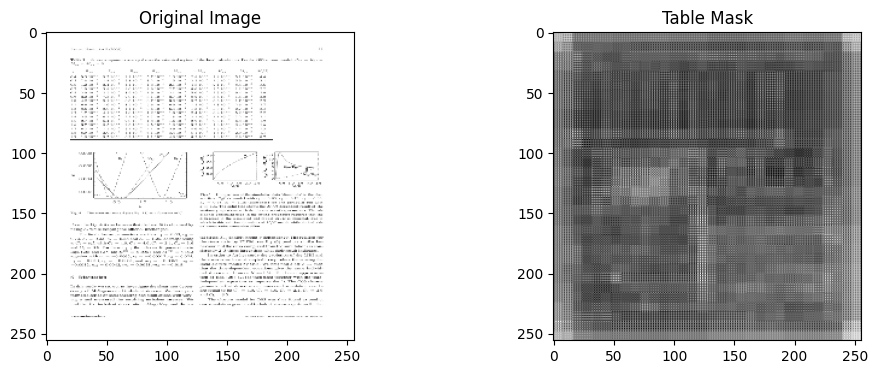

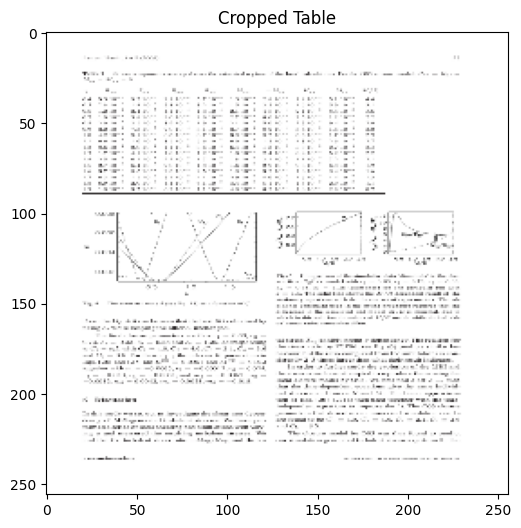

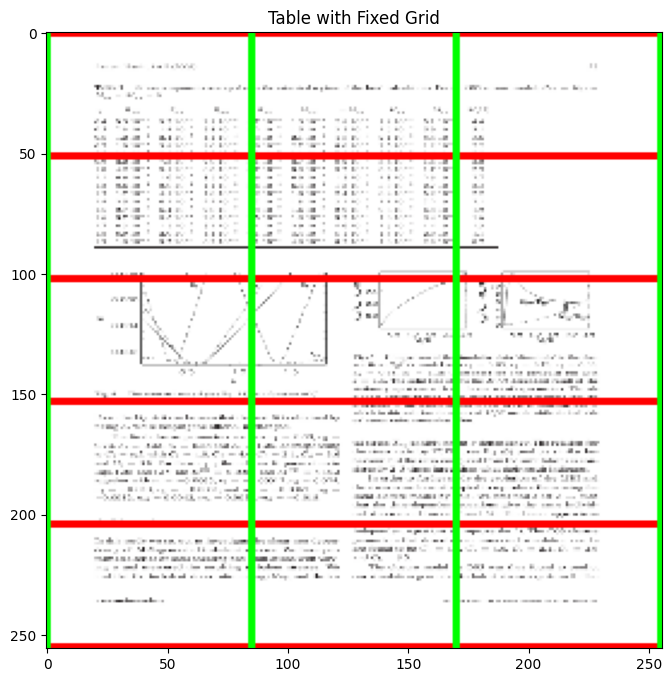

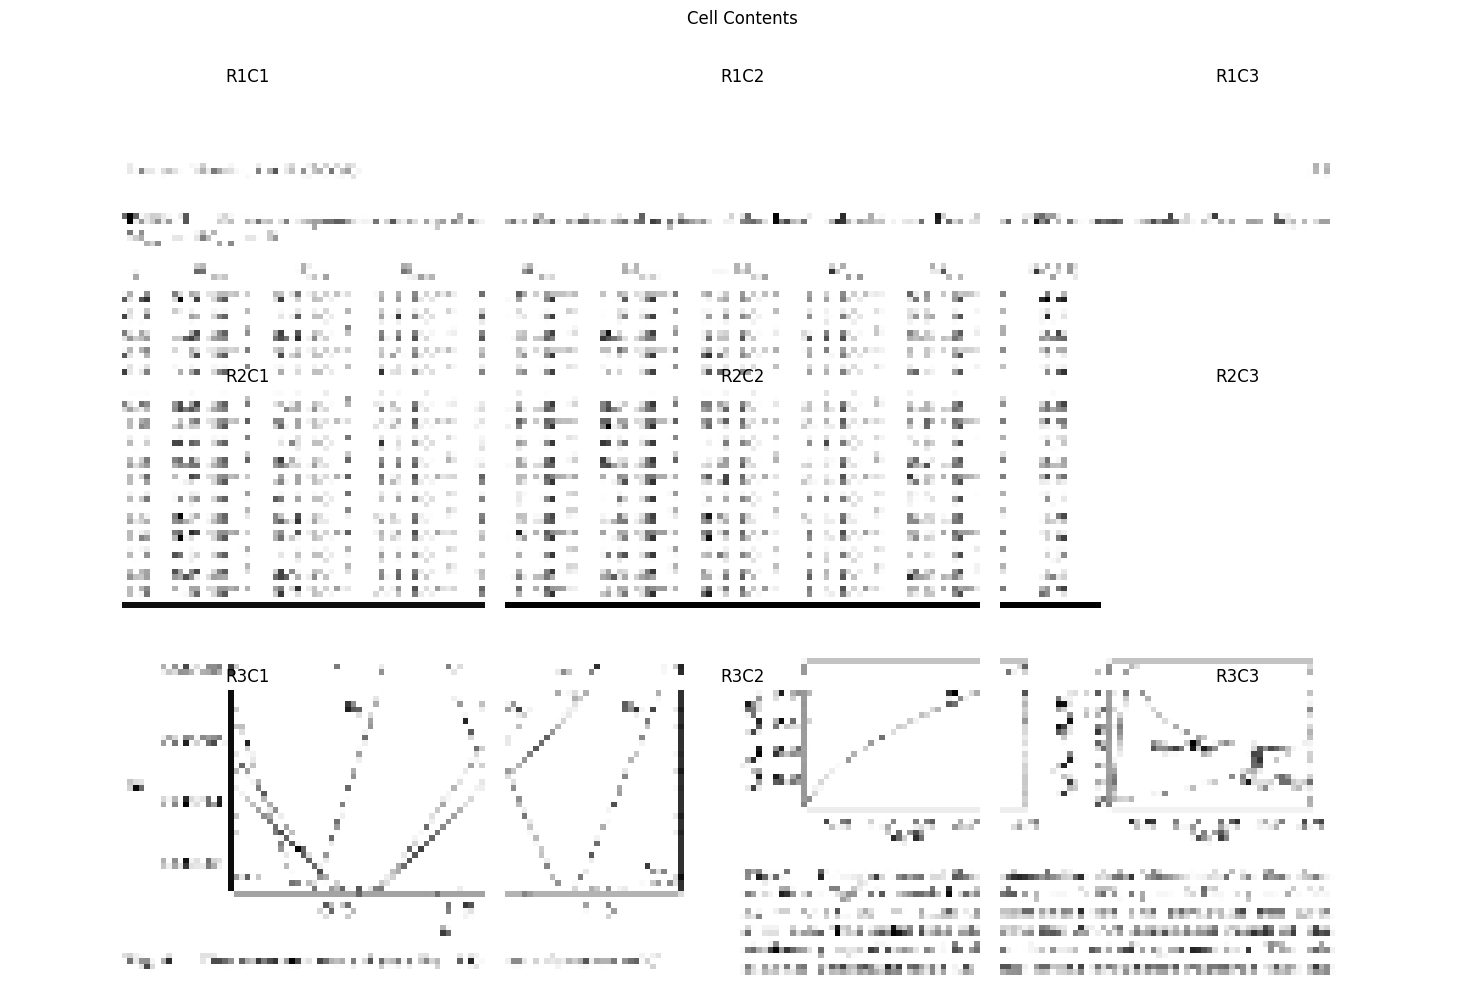

Table data saved to extracted_tables/table_fixed_grid_1.csv

Extracted table structure:
      0     1     2
0  R1C1  R1C2  R1C3
1  R2C1  R2C2  R2C3
2  R3C1  R3C2  R3C3
3  R4C1  R4C2  R4C3
4  R5C1  R5C2  R5C3


In [32]:
# Cell 1: Import libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import pandas as pd
import os
from tensorflow.keras.models import load_model

# Cell 2: Load model
model = load_model('model_66.keras')

# Cell 3: Simple fixed-grid table extraction function
def extract_table_fixed_grid(image, table_mask, output_csv_path, rows=5, cols=3):
    """Extract table using a fixed grid approach"""
    # Convert image to numpy if it's a tensor
    if isinstance(image, tf.Tensor):
        image = image.numpy()
    
    # Ensure image is uint8
    if image.dtype != np.uint8:
        image = (image * 255).astype(np.uint8)
    
    # Convert mask to binary uint8
    table_mask = (table_mask > 0.5).astype(np.uint8)
    
    # Find table contour
    contours, _ = cv2.findContours(table_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        print("No table found in image")
        return None
    
    # Get the largest contour (assumed to be the table)
    table_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(table_contour)
    
    # Crop the table region
    table_roi = image[y:y+h, x:x+w]
    
    # Display cropped table
    plt.figure(figsize=(10, 6))
    plt.imshow(table_roi)
    plt.title("Cropped Table")
    plt.show()
    
    # Create a fixed grid
    row_height = h // rows
    col_width = w // cols
    
    # Calculate grid lines
    row_lines = [i * row_height for i in range(rows+1)]
    col_lines = [j * col_width for j in range(cols+1)]
    
    # Visualize the grid
    grid_img = table_roi.copy()
    for r in row_lines:
        cv2.line(grid_img, (0, r), (w, r), (255, 0, 0), 2)
    for c in col_lines:
        cv2.line(grid_img, (c, 0), (c, h), (0, 255, 0), 2)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(grid_img)
    plt.title("Table with Fixed Grid")
    plt.show()
    
    # Convert to grayscale
    if len(table_roi.shape) == 3:
        gray_roi = cv2.cvtColor(table_roi, cv2.COLOR_RGB2GRAY)
    else:
        gray_roi = table_roi
    
    # Create cell data matrix
    data = []
    cell_imgs = []
    
    # Extract and display each cell
    plt.figure(figsize=(15, 10))
    plt.suptitle("Cell Contents")
    
    for i in range(rows):
        row_data = []
        for j in range(cols):
            # Get cell boundaries
            y1 = row_lines[i]
            y2 = row_lines[i+1]
            x1 = col_lines[j]
            x2 = col_lines[j+1]
            
            # Extract cell
            cell = gray_roi[y1:y2, x1:x2]
            cell_imgs.append(cell)
            
            # Add to table data with cell coordinates
            cell_id = f"R{i+1}C{j+1}"
            row_data.append(cell_id)
            
            # Display cell (only for the first few rows)
            if i < 3:  # Only show first 3 rows to avoid too many plots
                plt.subplot(3, cols, i*cols + j + 1)
                plt.imshow(cell, cmap='gray')
                plt.title(cell_id)
                plt.axis('off')
        
        data.append(row_data)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()
    
    # Convert to DataFrame and save
    df = pd.DataFrame(data)
    df.to_csv(output_csv_path, index=False, header=False)
    print(f"Table data saved to {output_csv_path}")
    
    return df, cell_imgs

# Cell 4: Process an image and extract table
output_dir = "extracted_tables"
os.makedirs(output_dir, exist_ok=True)

# Process one image
for idx, (image, mask) in enumerate(test_dataset.take(1)):
    print(f"Processing image {idx+1}")
    
    # Predict masks
    pred_table_mask, pred_column_mask = model.predict(tf.expand_dims(image[0], axis=0))
    
    # Get table mask
    table_mask = pred_table_mask[0, ..., 0]
    
    # Display original image and mask
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(image[0])
    plt.title("Original Image")
    
    plt.subplot(1, 2, 2)
    plt.imshow(table_mask, cmap='gray')
    plt.title("Table Mask")
    plt.show()
    
    # Extract table using fixed grid (5 rows x 3 columns)
    output_csv = os.path.join(output_dir, f"table_fixed_grid_{idx+1}.csv")
    df, cell_imgs = extract_table_fixed_grid(image[0], table_mask, output_csv)
    
    # Print resulting table structure
    print("\nExtracted table structure:")
    print(df)